In [2]:
print("Forecasting By Using ARIMA & PROPHET")

Forecasting By Using ARIMA & PROPHET


# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Load Clean Data

In [3]:
DATA_PATH = "../data/processed/clean_children_data.csv"
df = pd.read_csv(DATA_PATH)

In [4]:
df

,date,cbp_daily_intake,cbp_custody,cbp_transfers_to_hhs,hhs_care,hhs_discharges,total_system_load,net_daily_intake,care_load_growth_rate,backlog_indicator,discharge_offset_ratio
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0,6619.0,-402.0,NaN,False,12.823529
1,2023-01-22,32.0,49.0,39.0,7122.0,227.0,7171.0,-188.0,8.339628,False,5.820513
2,2023-01-23,32.0,50.0,39.0,7280.0,181.0,7330.0,-142.0,2.217264,False,4.641026
3,2023-01-24,47.0,42.0,47.0,7433.0,175.0,7475.0,-128.0,1.978172,False,3.723404
4,2023-01-25,20.0,22.0,41.0,7538.0,180.0,7560.0,-139.0,1.137124,False,4.390244
...,...,...,...,...,...,...,...,...,...,...,...
715,2025-12-15,11.0,42.0,9.0,2470.0,7.0,2512.0,2.0,0.600721,True,0.777778
716,2025-12-16,8.0,54.0,15.0,2468.0,9.0,2522.0,6.0,0.398089,True,0.600000
717,2025-12-17,7.0,31.0,11.0,2481.0,10.0,2512.0,1.0,-0.396511,True,0.909091
718,2025-12-18,11.0,50.0,6.0,2472.0,16.0,2522.0,-10.0,0.398089,False,2.666667


In [5]:
df.dtypes

date                       object
cbp_daily_intake          float64
cbp_custody               float64
cbp_transfers_to_hhs      float64
hhs_care                  float64
hhs_discharges            float64
total_system_load         float64
net_daily_intake          float64
care_load_growth_rate     float64
backlog_indicator            bool
discharge_offset_ratio    float64
dtype: object

In [6]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

In [7]:
df

,date,cbp_daily_intake,cbp_custody,cbp_transfers_to_hhs,hhs_care,hhs_discharges,total_system_load,net_daily_intake,care_load_growth_rate,backlog_indicator,discharge_offset_ratio
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0,6619.0,-402.0,NaN,False,12.823529
1,2023-01-22,32.0,49.0,39.0,7122.0,227.0,7171.0,-188.0,8.339628,False,5.820513
2,2023-01-23,32.0,50.0,39.0,7280.0,181.0,7330.0,-142.0,2.217264,False,4.641026
3,2023-01-24,47.0,42.0,47.0,7433.0,175.0,7475.0,-128.0,1.978172,False,3.723404
4,2023-01-25,20.0,22.0,41.0,7538.0,180.0,7560.0,-139.0,1.137124,False,4.390244
...,...,...,...,...,...,...,...,...,...,...,...
715,2025-12-15,11.0,42.0,9.0,2470.0,7.0,2512.0,2.0,0.600721,True,0.777778
716,2025-12-16,8.0,54.0,15.0,2468.0,9.0,2522.0,6.0,0.398089,True,0.600000
717,2025-12-17,7.0,31.0,11.0,2481.0,10.0,2512.0,1.0,-0.396511,True,0.909091
718,2025-12-18,11.0,50.0,6.0,2472.0,16.0,2522.0,-10.0,0.398089,False,2.666667


In [8]:
df.dtypes

date                      datetime64[ns]
cbp_daily_intake                 float64
cbp_custody                      float64
cbp_transfers_to_hhs             float64
hhs_care                         float64
hhs_discharges                   float64
total_system_load                float64
net_daily_intake                 float64
care_load_growth_rate            float64
backlog_indicator                   bool
discharge_offset_ratio           float64
dtype: object

In [9]:
ts = df.set_index("date")["total_system_load"]

In [10]:
ts

date
2023-01-12    6619.0
2023-01-22    7171.0
2023-01-23    7330.0
2023-01-24    7475.0
2023-01-25    7560.0
               ...  
2025-12-15    2512.0
2025-12-16    2522.0
2025-12-17    2512.0
2025-12-18    2522.0
2025-12-21    2502.0
Name: total_system_load, Length: 720, dtype: float64

# Train-Test Split (Time Based)

In [11]:
train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 576
Test size: 144


# Stationarity Check (ADF Test)

In [12]:
result = adfuller(train)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.0394655909660206
p-value: 0.738599467492491


# Fit ARIMA Model

In [13]:
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:      total_system_load   No. Observations:                  576
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3710.850
Date:                Tue, 17 Feb 2026   AIC                           7427.699
Time:                        17:32:22   BIC                           7440.762
Sample:                             0   HQIC                          7432.794
                                - 576                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0164      0.223      0.074      0.941      -0.421       0.454
ma.L1          0.1852      0.221      0.838      0.402      -0.248       0.618
sigma2      2.366e+04    846.125     27.963      0.0

# Forecast

In [14]:
forecast = model_fit.forecast(steps=len(test))

In [15]:
forecast

576    2421.961112
577    2421.944056
578    2421.943776
579    2421.943772
580    2421.943771
          ...     
715    2421.943771
716    2421.943771
717    2421.943771
718    2421.943771
719    2421.943771
Name: predicted_mean, Length: 144, dtype: float64

# Evaulation Metrics

In [16]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("ARIMA MAE:", mae)
print("ARIMA RMSE:", rmse)
print("ARIMA MAPE:", mape)

ARIMA MAE: 185.94945217741508
ARIMA RMSE: 227.25226601380965
ARIMA MAPE: nan


# Plot Results

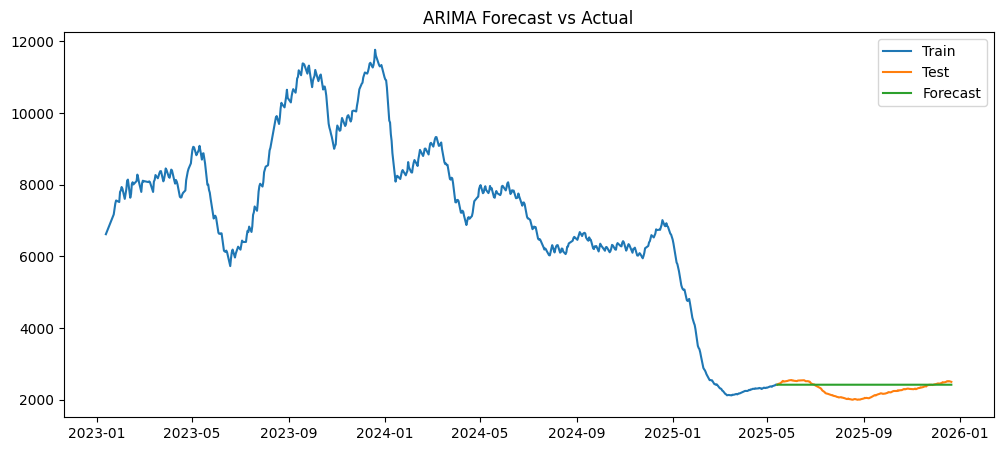

In [17]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()